# Chapter 5: Data Exploration 2

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from matplotlib import pyplot as plt

## 5.1 Introduction & Problem Setting

Now that you know quite a bit about analysing data, it's time to put this into practise! Today you will be analysing the 'Air crash dataset', an interesting dataset containing lots of information about different airplane crashes since 1908. You'll be looking at the data and hopefully make some interesting discoveries/conclusions!

During this exercise you will be comparing two operators: 'Aeroflot' and 'Military - U.S. Air Force'.

## 5.2 Data Loading & exploration

First, load in the data. Explore it by looking at the columns, datatypes, size, null values, ...

Also, create your two subsets, one for each of the operators you will be comparing ('Aeroflot' and 'Military - U.S. Air Force')

In [3]:
crash = pd.read_csv("Airplane_Crashes_and_Fatalities_Since_1908.csv")
crash.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [4]:
crash.shape

(5268, 13)

In [5]:
crash.dtypes

Date             object
Time             object
Location         object
Operator         object
Flight #         object
Route            object
Type             object
Registration     object
cn/In            object
Aboard          float64
Fatalities      float64
Ground          float64
Summary          object
dtype: object

In [6]:
crash.isna().describe()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
count,5268,5268,5268,5268,5268,5268,5268,5268,5268,5268,5268,5268,5268
unique,1,2,2,2,2,2,2,2,2,2,2,2,2
top,False,False,False,False,True,False,False,False,False,False,False,False,False
freq,5268,3049,5248,5250,4199,3561,5241,4933,4040,5246,5256,5246,4878


In [7]:
US = crash.loc[crash['Operator'] == 'Military - U.S. Air Force']
Aeroflot = crash.loc[crash['Operator'] == 'Aeroflot']

## 5.3: Excercises

### 5.3.1: Make a histogram of both datasets and compare them. We are only interested in the amount of fatalities per operator. What does this tell you?

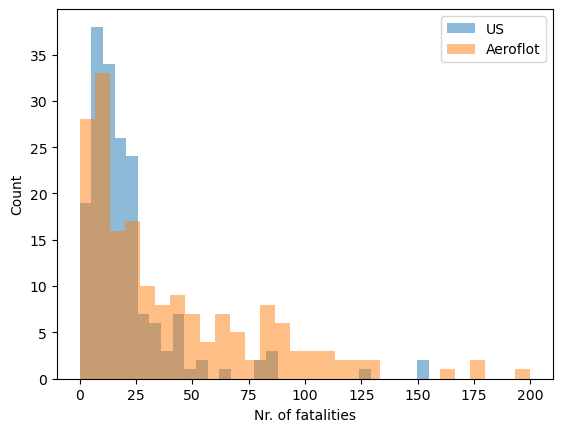

In [14]:
plt.hist(US['Fatalities'], label = "US", alpha = 0.5, bins = 30) 
plt.hist(Aeroflot['Fatalities'], label = "Aeroflot", alpha = 0.5, bins = 30) 
plt.xlabel('Nr. of fatalities')
plt.ylabel('Count')
plt.legend();

We can see that both dataset have a similar distribution of fatalities. That being said, the Aeroflot dataset seems to be a bit more spread out than the US dataset, which is more clustered together. The US dataset seems to have more outliers however.

### 5.3.2: Make a boxplot to compare the data. Does this give you any more information?

- Which one has one average more deaths?
- Do the medians tell the same story?
- What about the standard deviation/IQR

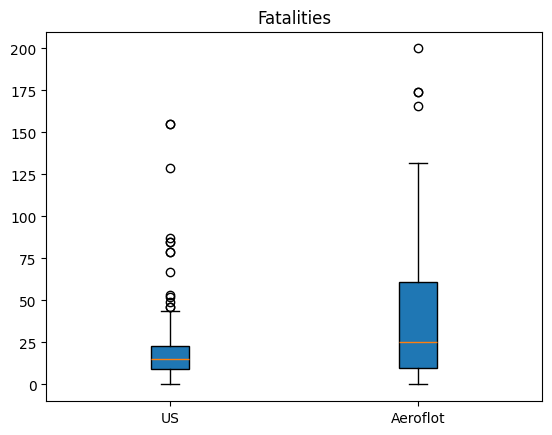

In [10]:
boxplot_data_list = [US['Fatalities'],
                    Aeroflot['Fatalities']]

boxplot_data_labels = ['US', "Aeroflot"]
plt.title('Fatalities')
plt.boxplot(boxplot_data_list, tick_labels = boxplot_data_labels, patch_artist=True);

In [11]:
print(US['Fatalities'].mean())
print(US['Fatalities'].median())
print(np.sqrt(np.var(US['Fatalities'])))

print('')

print(Aeroflot['Fatalities'].mean())
print(Aeroflot['Fatalities'].median())
print(np.sqrt(np.var(Aeroflot['Fatalities'])))

21.119318181818183
15.0
22.97509698245702

39.977653631284916
25.0
39.49979920849363


The boxplot confirms the theory that the fatalities in the Aeroflot dataset are more spread out. It also confirms that the US dataset has way more outliers.

When looking at the mean, we can see that Aeroflot is almost double that of US! The median is also bigger, although the difference lowers a bit.

The standard deviation once again supports our spread out theory, as it is bigger for the Aeroflot dataset.

### 5.3.3: Calculate the proportion of passengers killed in the crash. Make a boxplot out of this data for both US military and Aeroflot. What can you conclude?

In [20]:
US['Perc_deceased'] = US['Fatalities'] / US['Aboard']
Aeroflot['Perc_deceased'] = Aeroflot['Fatalities'] / Aeroflot['Aboard']

US.head()

C:\Users\rikto\AppData\Local\Temp\ipykernel_16828\3865324422.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  US['Perc_deceased'] = US['Fatalities'] / US['Aboard']
C:\Users\rikto\AppData\Local\Temp\ipykernel_16828\3865324422.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Aeroflot['Perc_deceased'] = Aeroflot['Fatalities'] / Aeroflot['Aboard']


,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary,Perc_deceased
622,08/07/1943,05:20,"Off Townsville, Australia",Military - U.S. Air Force,NaN,Townsville - Brisbane,Douglas C-47-DL,41-7733,4212,27.0,27.0,0.0,Crashed into the ocean.,1.0
637,12/19/1943,09:20,"Canal Creek, Australia",Military - U.S. Air Force,NaN,NaN,Douglas C-47A-60-DL,43-30742,13893,31.0,31.0,0.0,NaN,1.0
662,08/23/1944,10:45,"Freckelton, England",Military - U.S. Air Force,NaN,NaN,Consolidated B-24H,42-50291,NaN,3.0,3.0,58.0,The bomber crashed into a school and a cafe wh...,1.0
670,06/30/1945,NaN,Texas,Military - U.S. Air Force,NaN,NaN,Boeing TB-29A Super Fortress,44-69943,NaN,12.0,12.0,0.0,NaN,1.0
700,03/27/1945,NaN,"Coral Sea, off Australia",Military - U.S. Air Force,NaN,NaN,Douglas C-47A-90-DL,43-16011,20477,24.0,24.0,0.0,Disappeared en route.,1.0


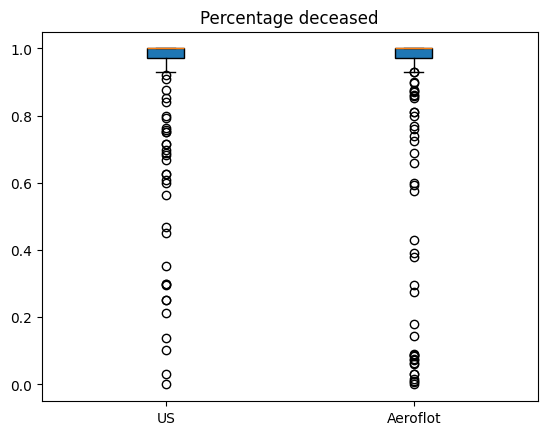

In [21]:
boxplot_data_list = [US['Perc_deceased'],
                    Aeroflot['Perc_deceased']]

boxplot_data_labels = ['US', "Aeroflot"]
plt.title('Percentage deceased')
plt.boxplot(boxplot_data_list, tick_labels = boxplot_data_labels, patch_artist=True);

When looking at the boxplots we can see that the vast majority of plane crashes killed close to 100% of their passengers. There are however some outliers.

For the US subset, these outliers are grouped closer to the 100%, while for the Aeroflot subset they are grouped closer to the 0%. This could mean that it is more common to have close to no fatalities in a flight crash when the operator is Aeroflot then the US.

### 5.3.4: Make a scatterplot of fatalities over time. Do the number of fatalities improve over time or not? Compare once again US military vs Aeroflot.

First, let's look at the format of the data and conver the dates.

In [23]:
US.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary,Perc_deceased
622,08/07/1943,05:20,"Off Townsville, Australia",Military - U.S. Air Force,NaN,Townsville - Brisbane,Douglas C-47-DL,41-7733,4212,27.0,27.0,0.0,Crashed into the ocean.,1.0
637,12/19/1943,09:20,"Canal Creek, Australia",Military - U.S. Air Force,NaN,NaN,Douglas C-47A-60-DL,43-30742,13893,31.0,31.0,0.0,NaN,1.0
662,08/23/1944,10:45,"Freckelton, England",Military - U.S. Air Force,NaN,NaN,Consolidated B-24H,42-50291,NaN,3.0,3.0,58.0,The bomber crashed into a school and a cafe wh...,1.0
670,06/30/1945,NaN,Texas,Military - U.S. Air Force,NaN,NaN,Boeing TB-29A Super Fortress,44-69943,NaN,12.0,12.0,0.0,NaN,1.0
700,03/27/1945,NaN,"Coral Sea, off Australia",Military - U.S. Air Force,NaN,NaN,Douglas C-47A-90-DL,43-16011,20477,24.0,24.0,0.0,Disappeared en route.,1.0


In [25]:
US['Date'] = pd.to_datetime(US['Date'], format='%m/%d/%Y')
Aeroflot['Date'] = pd.to_datetime(Aeroflot['Date'], format='%m/%d/%Y')

C:\Users\rikto\AppData\Local\Temp\ipykernel_16828\2589143988.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  US['Date'] = pd.to_datetime(US['Date'], format='%m/%d/%Y')
C:\Users\rikto\AppData\Local\Temp\ipykernel_16828\2589143988.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Aeroflot['Date'] = pd.to_datetime(Aeroflot['Date'], format='%m/%d/%Y')


In [27]:
US.dtypes

Date             datetime64[ns]
Time                     object
Location                 object
Operator                 object
Flight #                 object
Route                    object
Type                     object
Registration             object
cn/In                    object
Aboard                  float64
Fatalities              float64
Ground                  float64
Summary                  object
Perc_deceased           float64
dtype: object

Now, let's plot the data.

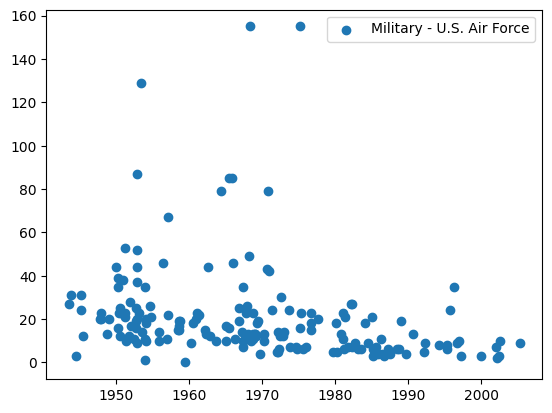

In [33]:
plt.scatter(US['Date'], US['Fatalities'], color = 'tab:blue', label='Military - U.S. Air Force')
plt.legend()

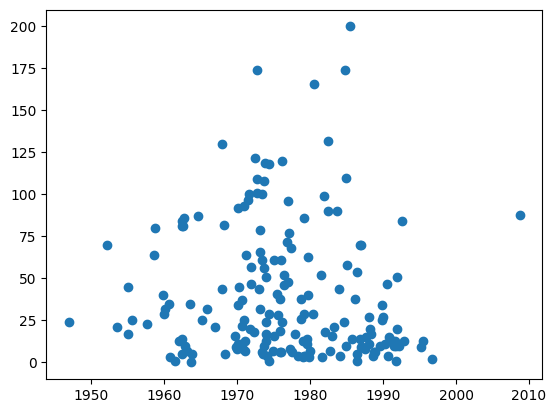

In [29]:
plt.scatter(Aeroflot['Date'], Aeroflot['Fatalities'], color = 'tab:blue', label='Aeroflot')

Let's try and improve this gradually.

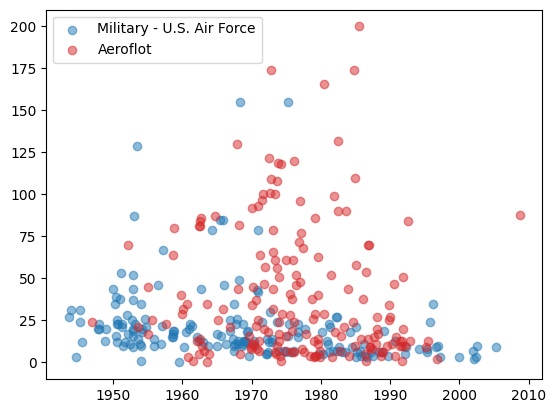

In [35]:
plt.scatter(US['Date'], US['Fatalities'], color = 'tab:blue', label='Military - U.S. Air Force', alpha=0.5)
plt.scatter(Aeroflot['Date'], Aeroflot['Fatalities'], color = 'tab:red', label='Aeroflot', alpha=0.5)
plt.legend()

C:\Users\rikto\AppData\Local\Temp\ipykernel_16828\1134758105.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  US['Year'] = US['Date'].dt.year
C:\Users\rikto\AppData\Local\Temp\ipykernel_16828\1134758105.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Aeroflot['Year'] = Aeroflot['Date'].dt.year


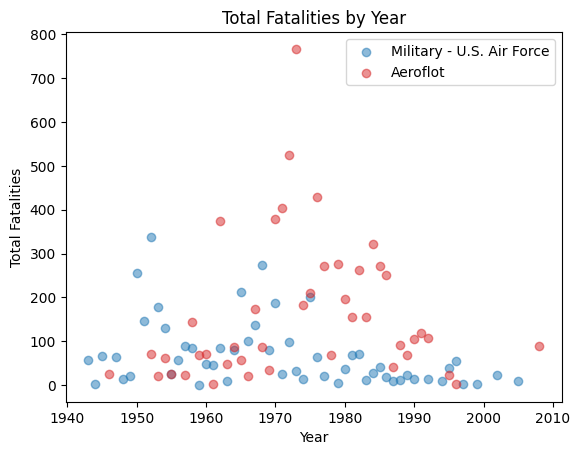

In [36]:
US['Year'] = US['Date'].dt.year
US_yearly_data = US.groupby('Year')['Fatalities'].sum().reset_index()

Aeroflot['Year'] = Aeroflot['Date'].dt.year
Aeroflot_yearly_data = Aeroflot.groupby('Year')['Fatalities'].sum().reset_index()

# Plot the total fatalities per year
plt.scatter(US_yearly_data['Year'], US_yearly_data['Fatalities'], color = 'tab:blue', label='Military - U.S. Air Force', alpha=0.5)
plt.scatter(Aeroflot_yearly_data['Year'], Aeroflot_yearly_data['Fatalities'], color = 'tab:red', label='Aeroflot', alpha=0.5)
plt.xlabel('Year')
plt.ylabel('Total Fatalities')
plt.title('Total Fatalities by Year')
plt.legend()

We can see that the for both operators, the total amount of fatalities lowers as the years go on. That being said, we see that the US subset peaks at the beginning (1950), while the Aeroflot subset peaks in the middle (1975).